#**Research Project**
##**Check how age and gender affect ASD (Children Dataset)**

###Conducted by Christel AL HAGE
###With the supervision of Dr. Mounim EL YACOUBI and Dr. Jihyun MUN

Dataset used:
https://www.kaggle.com/datasets/uppulurimadhuri/dataset/code/discussion

**Step 1: Setup and Data Preprocessing**

In [ ]:
!pip install shap xgboost

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [ ]:
# Load the new clinical dataset
df = pd.read_csv('data_csv.csv')

# Define our features
# We are combining behavioral questions (A1-A10), demographics, and clinical comorbidities!
features = [
    'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10_Autism_Spectrum_Quotient',
    'Age_Years', 'Sex', 'Jaundice', 'Family_mem_with_ASD',
    'Speech Delay/Language Disorder', 'Learning disorder', 'Genetic_Disorders',
    'Depression', 'Global developmental delay/intellectual disability',
    'Social/Behavioural Issues', 'Anxiety_disorder'
]
target_col = 'ASD_traits'

# Drop rows where the target is missing, just in case
df = df.dropna(subset=[target_col])

# Clean and encode the data (handling any text/objects like "Yes"/"No" or "M"/"F")
encoder = LabelEncoder()
for col in features + [target_col]:
    # Fill missing values with 'Missing' for text or -1 for numbers before encoding
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Missing')
        df[col] = encoder.fit_transform(df[col].astype(str))
    else:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(-1)

# Split the data
X = df[features]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Step 2: Train the XGBoost Model & Evaluate Demographics**

In [ ]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=pos_weight,
    random_state=42
)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)
print(f"--- Overall Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}% ---\n")

# Stratified Demographic Analysis
results_df = X_test.copy()
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred

print("--- Accuracy by Sex (0=Female, 1=Male) ---")
# Note: Check your specific encoding, but usually F=0, M=1
print(results_df.groupby('Sex').apply(lambda x: accuracy_score(x['Actual'], x['Predicted']) * 100))

print("\n--- Accuracy by Age Group (Years) ---")
# Binning ages into standard developmental stages: Toddler/Preschool, Grade School, Middle, High School
results_df['Age_Group'] = pd.cut(results_df['Age_Years'], bins=[0, 5, 10, 14, 18])
print(results_df.groupby('Age_Group').apply(lambda x: accuracy_score(x['Actual'], x['Predicted']) * 100))

--- Overall Model Accuracy: 87.91% ---

--- Accuracy by Sex (0=Female, 1=Male) ---
Sex
0    99.074074
1    83.737024
dtype: float64

--- Accuracy by Age Group (Years) ---
Age_Group
(0, 5]      94.252874
(5, 10]     85.211268
(10, 14]    84.892086
(14, 18]    96.551724
dtype: float64


/tmp/ipykernel_522/2700187736.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(results_df.groupby('Sex').apply(lambda x: accuracy_score(x['Actual'], x['Predicted']) * 100))
/tmp/ipykernel_522/2700187736.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(results_df.groupby('Age_Group').apply(lambda x: accuracy_score(x['Actual'], x['Predicted']) * 100))
/tmp/ipykernel_522/2700187736.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated

**Step 3: Generate SHAP Plots**

Generating SHAP Summary Plot...


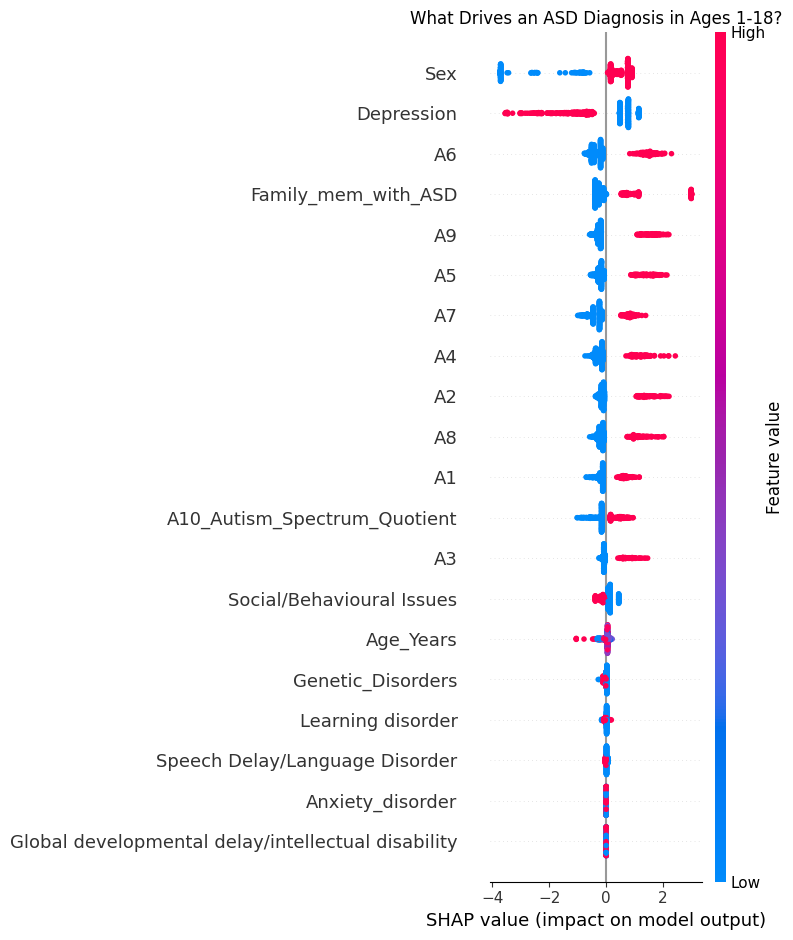


Generating Age vs. Speech Delay Interaction Plot...


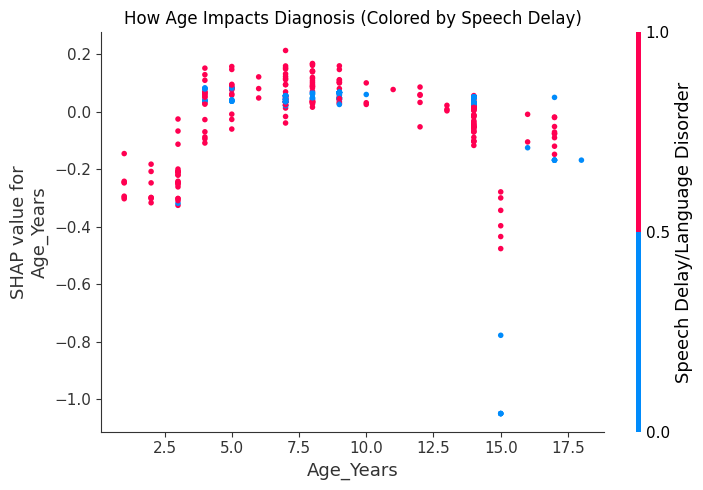

In [ ]:
# Initialize the SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Set up the plot styling
plt.style.use('default')

# SHAP Summary Plot (Feature Importance)
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test, show=False)
plt.title("What Drives an ASD Diagnosis in Ages 1-18?")
plt.tight_layout()
plt.show()

# SHAP Dependence Plot for Age vs. Speech Delay
print("\nGenerating Age vs. Speech Delay Interaction Plot...")
shap.dependence_plot(
    "Age_Years",
    shap_values,
    X_test,
    interaction_index="Speech Delay/Language Disorder",
    show=False
)
plt.title("How Age Impacts Diagnosis (Colored by Speech Delay)")
plt.tight_layout()
plt.show()

**Step 4: Subgroup Experiment**

In [ ]:
print("\n" + "="*58)
print("     EXPERIMENT 1: GENDER STRATIFICATION (GIRLS VS BOYS)  ")
print("="*58)

# Define a helper function to train an isolated model
def train_isolated_model(subset_df, subgroup_name):
    # If a subgroup is too small, we skip it to avoid errors
    if len(subset_df) < 20:
        return f"{subgroup_name: <30} | Not enough data!"

    X_sub = subset_df[features]
    y_sub = subset_df[target_col]

    # Stratified split to ensure we get both ASD and non-ASD cases in the test set
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
    )

    # Handle class imbalance for this specific subgroup
    pos_weight_sub = (y_train_sub == 0).sum() / (y_train_sub == 1).sum() if (y_train_sub == 1).sum() > 0 else 1

    # Train the model strictly on this subgroup
    sub_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        scale_pos_weight=pos_weight_sub,
        random_state=42
    )
    sub_model.fit(X_train_sub, y_train_sub)

    # Test the model and get accuracy
    preds = sub_model.predict(X_test_sub)
    acc = accuracy_score(y_test_sub, preds) * 100

    return f"{subgroup_name: <30} | Accuracy: {acc:.2f}%  |  (Test Pool Size: {len(y_test_sub)})"

# Run Gender Subgroups
# In our previous Label Encoding, Sex is encoded alphabetically: 'F' -> 0, 'M' -> 1
df_girls = df[df['Sex'] == 0]
df_boys  = df[df['Sex'] == 1]

print(train_isolated_model(df_girls, "Model 1: Strictly Girls"))
print(train_isolated_model(df_boys,  "Model 2: Strictly Boys"))


# Run Age Subgroups
print("\n" + "="*58)
print("     EXPERIMENT 2: AGE STRATIFICATION (DEVELOPMENTAL)     ")
print("="*58)

# Bins: Early Childhood (1-5), Grade School (6-10), Middle (11-14), High School (15-18)
df_early = df[(df['Age_Years'] >= 1) & (df['Age_Years'] <= 5)]
df_grade = df[(df['Age_Years'] >= 6) & (df['Age_Years'] <= 10)]
df_mid   = df[(df['Age_Years'] >= 11) & (df['Age_Years'] <= 14)]
df_high  = df[(df['Age_Years'] >= 15) & (df['Age_Years'] <= 18)]

print(train_isolated_model(df_early, "Model 3: Ages 1-5 (Early)"))
print(train_isolated_model(df_grade, "Model 4: Ages 6-10 (Grade)"))
print(train_isolated_model(df_mid,   "Model 5: Ages 11-14 (Middle)"))
print(train_isolated_model(df_high,  "Model 6: Ages 15-18 (High)"))
print("="*58 + "\n")


     EXPERIMENT 1: GENDER STRATIFICATION (GIRLS VS BOYS)  
Model 1: Strictly Girls        | Accuracy: 97.22%  |  (Test Pool Size: 108)
Model 2: Strictly Boys         | Accuracy: 84.83%  |  (Test Pool Size: 290)

     EXPERIMENT 2: AGE STRATIFICATION (DEVELOPMENTAL)     
Model 3: Ages 1-5 (Early)      | Accuracy: 89.41%  |  (Test Pool Size: 85)
Model 4: Ages 6-10 (Grade)     | Accuracy: 83.33%  |  (Test Pool Size: 150)
Model 5: Ages 11-14 (Middle)   | Accuracy: 87.12%  |  (Test Pool Size: 132)
Model 6: Ages 15-18 (High)     | Accuracy: 93.55%  |  (Test Pool Size: 31)

